# Imports


In [159]:
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import date as date
import yfinance as yf
import re
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt

# Data Management

In [160]:
# Data extraction
start_date = '2019-09-18'
end_date = date.today()
symbol = 'HBAR-USD'
data = yf.download(symbol, start_date, end_date)
data

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,HBAR-USD,HBAR-USD,HBAR-USD,HBAR-USD,HBAR-USD
Date,,,,,
2019-09-18,0.086921,0.100272,0.080045,0.090519,14772274
2019-09-19,0.057924,0.087721,0.054469,0.087702,27324784
2019-09-20,0.052490,0.059061,0.047800,0.058087,15814443
2019-09-21,0.048021,0.055408,0.045456,0.052402,13144171
2019-09-22,0.039735,0.048237,0.038757,0.048065,10549578
...,...,...,...,...,...
2025-03-16,0.185202,0.194836,0.182333,0.192705,271502752
2025-03-17,0.191654,0.195641,0.184834,0.185198,289292129


In [161]:
print(data)

Price          Close      High       Low      Open     Volume
Ticker      HBAR-USD  HBAR-USD  HBAR-USD  HBAR-USD   HBAR-USD
Date                                                         
2019-09-18  0.086921  0.100272  0.080045  0.090519   14772274
2019-09-19  0.057924  0.087721  0.054469  0.087702   27324784
2019-09-20  0.052490  0.059061  0.047800  0.058087   15814443
2019-09-21  0.048021  0.055408  0.045456  0.052402   13144171
2019-09-22  0.039735  0.048237  0.038757  0.048065   10549578
...              ...       ...       ...       ...        ...
2025-03-16  0.185202  0.194836  0.182333  0.192705  271502752
2025-03-17  0.191654  0.195641  0.184834  0.185198  289292129
2025-03-18  0.188550  0.191653  0.182473  0.191653  187394999
2025-03-19  0.197475  0.198151  0.186299  0.188550  301597299
2025-03-20  0.189850  0.199012  0.187548  0.197496  227046282

[2011 rows x 5 columns]


In [162]:
data.head(10)

Price,Close,High,Low,Open,Volume
Ticker,HBAR-USD,HBAR-USD,HBAR-USD,HBAR-USD,HBAR-USD
Date,,,,,
2019-09-18,0.086921,0.100272,0.080045,0.090519,14772274
2019-09-19,0.057924,0.087721,0.054469,0.087702,27324784
2019-09-20,0.052490,0.059061,0.047800,0.058087,15814443
2019-09-21,0.048021,0.055408,0.045456,0.052402,13144171
2019-09-22,0.039735,0.048237,0.038757,0.048065,10549578
2019-09-23,0.037645,0.039803,0.035488,0.039739,11214860
2019-09-24,0.029641,0.043997,0.029084,0.037689,12197101
2019-09-25,0.030202,0.031111,0.025871,0.029515,8906428


In [163]:
data.tail(10)

Price,Close,High,Low,Open,Volume
Ticker,HBAR-USD,HBAR-USD,HBAR-USD,HBAR-USD,HBAR-USD
Date,,,,,
2025-03-11,0.195807,0.203500,0.180726,0.189429,633052141
2025-03-12,0.200960,0.214328,0.193305,0.195807,605417094
2025-03-13,0.189250,0.202045,0.184279,0.200960,418932757
2025-03-14,0.191889,0.198503,0.187881,0.189250,309365663
2025-03-15,0.192706,0.197011,0.190460,0.191885,223717313
2025-03-16,0.185202,0.194836,0.182333,0.192705,271502752
2025-03-17,0.191654,0.195641,0.184834,0.185198,289292129
2025-03-18,0.188550,0.191653,0.182473,0.191653,187394999


In [164]:
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,HBAR-USD,HBAR-USD,HBAR-USD,HBAR-USD,HBAR-USD
count,2011.000000,2011.000000,2011.000000,2011.000000,2.011000e+03
mean,0.115685,0.121258,0.110061,0.115681,1.434905e+08
std,0.103215,0.109500,0.097255,0.103277,3.484712e+08
min,0.010080,0.010667,0.010012,0.010054,4.019320e+05
25%,0.046740,0.048258,0.045432,0.046737,2.057366e+07
50%,0.064801,0.066986,0.062373,0.064797,4.706229e+07
75%,0.180422,0.189666,0.170569,0.180446,1.196367e+08
max,0.505923,0.570146,0.462120,0.505475,6.950736e+09


In [165]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2011 entries, 2019-09-18 to 2025-03-20
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Close, HBAR-USD)   2011 non-null   float64
 1   (High, HBAR-USD)    2011 non-null   float64
 2   (Low, HBAR-USD)     2011 non-null   float64
 3   (Open, HBAR-USD)    2011 non-null   float64
 4   (Volume, HBAR-USD)  2011 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 94.3 KB


In [166]:
def unify_column_names(name: str) -> str:
    """Converts column names to lowercase, replaces spaces/hyphens with underscores, and handles MultiIndex."""
    return (
        tuple(re.sub(r"[-\s]+", "_", str(n).lower()) for n in name)
        if isinstance(name, tuple)
        else re.sub(r"[-\s]+", "_", str(name).lower())
    )


# Apply transformation to column names
data.columns = data.columns.map(unify_column_names)

In [167]:
print(f"Unified columns names: \n{data.columns}")

Unified columns names: 
MultiIndex([( 'close', 'hbar_usd'),
            (  'high', 'hbar_usd'),
            (   'low', 'hbar_usd'),
            (  'open', 'hbar_usd'),
            ('volume', 'hbar_usd')],
           names=['Price', 'Ticker'])


In [168]:
# Add returns and range
df = data.copy()
df["returns"] = df["close"].pct_change()
df["range"] = (df["high"] / df["low"]) - 1

In [169]:
df.head(10)

Price,close,high,low,open,volume,returns,range
Ticker,hbar_usd,hbar_usd,hbar_usd,hbar_usd,hbar_usd,,
Date,,,,,,,
2019-09-18,0.086921,0.100272,0.080045,0.090519,14772274,NaN,0.252695
2019-09-19,0.057924,0.087721,0.054469,0.087702,27324784,-0.333602,0.610476
2019-09-20,0.052490,0.059061,0.047800,0.058087,15814443,-0.093813,0.235586
2019-09-21,0.048021,0.055408,0.045456,0.052402,13144171,-0.085140,0.218937
2019-09-22,0.039735,0.048237,0.038757,0.048065,10549578,-0.172549,0.244601
2019-09-23,0.037645,0.039803,0.035488,0.039739,11214860,-0.052598,0.121590
2019-09-24,0.029641,0.043997,0.029084,0.037689,12197101,-0.212618,0.512756
2019-09-25,0.030202,0.031111,0.025871,0.029515,8906428,0.018926,0.202543


In [170]:
# Determine the total of NA values and drop them
na_count = df.isna().sum().sum()
if na_count > 0:
    print(f"Dropping {na_count} NA value(s)")
    df.dropna(inplace=True)

print(f"Length: {len(df)}")
df.head(10)

Dropping 1 NA value(s)
Length: 2010


Price,close,high,low,open,volume,returns,range
Ticker,hbar_usd,hbar_usd,hbar_usd,hbar_usd,hbar_usd,,
Date,,,,,,,
2019-09-19,0.057924,0.087721,0.054469,0.087702,27324784,-0.333602,0.610476
2019-09-20,0.052490,0.059061,0.047800,0.058087,15814443,-0.093813,0.235586
2019-09-21,0.048021,0.055408,0.045456,0.052402,13144171,-0.085140,0.218937
2019-09-22,0.039735,0.048237,0.038757,0.048065,10549578,-0.172549,0.244601
2019-09-23,0.037645,0.039803,0.035488,0.039739,11214860,-0.052598,0.121590
2019-09-24,0.029641,0.043997,0.029084,0.037689,12197101,-0.212618,0.512756
2019-09-25,0.030202,0.031111,0.025871,0.029515,8906428,0.018926,0.202543
2019-09-26,0.028966,0.031022,0.027305,0.030204,5190095,-0.040924,0.136129


In [171]:
# Add moving averages
df["ma_12"] = df["close"].rolling(window=12).mean()
df["ma_21"] = df["close"].rolling(window=21).mean()

In [172]:
df.head(500)

Price,close,high,low,open,volume,returns,range,ma_12,ma_21
Ticker,hbar_usd,hbar_usd,hbar_usd,hbar_usd,hbar_usd,,,,
Date,,,,,,,,,
2019-09-19,0.057924,0.087721,0.054469,0.087702,27324784,-0.333602,0.610476,NaN,NaN
2019-09-20,0.052490,0.059061,0.047800,0.058087,15814443,-0.093813,0.235586,NaN,NaN
2019-09-21,0.048021,0.055408,0.045456,0.052402,13144171,-0.085140,0.218937,NaN,NaN
2019-09-22,0.039735,0.048237,0.038757,0.048065,10549578,-0.172549,0.244601,NaN,NaN
2019-09-23,0.037645,0.039803,0.035488,0.039739,11214860,-0.052598,0.121590,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2021-01-26,0.090527,0.095400,0.085541,0.091911,79453877,-0.012899,0.115255,0.081562,0.067629
2021-01-27,0.080375,0.090512,0.078051,0.090512,62458671,-0.112143,0.159652,0.083658,0.069614


In [173]:
df.head(100)

Price,close,high,low,open,volume,returns,range,ma_12,ma_21
Ticker,hbar_usd,hbar_usd,hbar_usd,hbar_usd,hbar_usd,,,,
Date,,,,,,,,,
2019-09-19,0.057924,0.087721,0.054469,0.087702,27324784,-0.333602,0.610476,NaN,NaN
2019-09-20,0.052490,0.059061,0.047800,0.058087,15814443,-0.093813,0.235586,NaN,NaN
2019-09-21,0.048021,0.055408,0.045456,0.052402,13144171,-0.085140,0.218937,NaN,NaN
2019-09-22,0.039735,0.048237,0.038757,0.048065,10549578,-0.172549,0.244601,NaN,NaN
2019-09-23,0.037645,0.039803,0.035488,0.039739,11214860,-0.052598,0.121590,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2019-12-23,0.015638,0.018714,0.015071,0.018646,6095890,-0.161052,0.241722,0.020205,0.022039
2019-12-24,0.015223,0.015974,0.015122,0.015594,1229424,-0.026538,0.056342,0.019520,0.021606


In [174]:
# Structure Data
X_train = df[["returns", "range"]].iloc[:500]
X_test = df[["returns", "range"]].iloc[500:]
saved_df = df.iloc[500:]

print(f"Train Length: {len(X_train)}")
print(f"Test Length: {len(X_test)}")

print(f"X_train From: {X_train.head(1).index.item()}")
print(f"X_train To: {X_train.tail(1).index.item()}")
print(f"X_test From: {X_test.head(1).index.item()}")
print(f"X_test To: {X_test.tail(1).index.item()}")

saved_df.head(10)

Train Length: 500
Test Length: 1510
X_train From: 2019-09-19 00:00:00
X_train To: 2021-01-30 00:00:00
X_test From: 2021-01-31 00:00:00
X_test To: 2025-03-20 00:00:00


Price,close,high,low,open,volume,returns,range,ma_12,ma_21
Ticker,hbar_usd,hbar_usd,hbar_usd,hbar_usd,hbar_usd,,,,
Date,,,,,,,,,
2021-01-31,0.082122,0.085245,0.077118,0.081093,104353170,0.015369,0.105384,0.090791,0.076276
2021-02-01,0.087961,0.090081,0.078267,0.082122,98183204,0.071102,0.150945,0.089640,0.078395
2021-02-02,0.091941,0.097935,0.084542,0.087921,133753648,0.045247,0.158418,0.089266,0.080526
2021-02-03,0.094646,0.095145,0.089664,0.092003,88736896,0.029421,0.061128,0.089096,0.082502
2021-02-04,0.089659,0.095522,0.086632,0.094499,72781380,-0.052691,0.102618,0.088534,0.084050
2021-02-05,0.097405,0.097787,0.089316,0.089765,79447079,0.086394,0.094843,0.088829,0.086059
2021-02-06,0.102029,0.111682,0.097188,0.097727,132641741,0.047472,0.149134,0.089689,0.088070
2021-02-07,0.096312,0.103104,0.089953,0.101767,85797497,-0.056033,0.146199,0.090171,0.089737


# Train HMM

In [175]:
# Fit model
hmm_model = GaussianHMM(n_components=4, covariance_type="full", n_iter=1000, random_state=42)
hmm_model.fit(X_train)
hmm_model.predict(X_train)

array([3, 3, 3, 3, 3, 3, 0, 0, 1, 3, 3, 0, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 2, 2, 0, 0, 0, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0,
       0, 0, 2, 2, 0, 0, 0, 0, 0, 2, 2, 2, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2,
       0, 0, 0, 0, 2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 0, 0, 2, 2, 2, 0, 0, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 2, 0, 2, 2, 2, 2, 0, 0, 2, 2, 2,
       2, 2, 0, 0, 0, 1, 1, 1, 3, 0, 0, 0, 0, 1, 1, 3, 3, 3, 1, 3, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3,
       1, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 2, 2, 2, 2, 0, 0, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 0, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

In [176]:
# Make prediction on test data
df_main = saved_df.copy()
df_main.drop(columns=["high", "low"], inplace=True)

hmm_results = hmm_model.predict(X_test)
df_main["hmm"] = hmm_results
df_main.head(100)

Price,close,open,volume,returns,range,ma_12,ma_21,hmm
Ticker,hbar_usd,hbar_usd,hbar_usd,,,,,
Date,,,,,,,,
2021-01-31,0.082122,0.081093,104353170,0.015369,0.105384,0.090791,0.076276,3
2021-02-01,0.087961,0.082122,98183204,0.071102,0.150945,0.089640,0.078395,0
2021-02-02,0.091941,0.087921,133753648,0.045247,0.158418,0.089266,0.080526,0
2021-02-03,0.094646,0.092003,88736896,0.029421,0.061128,0.089096,0.082502,0
2021-02-04,0.089659,0.094499,72781380,-0.052691,0.102618,0.088534,0.084050,0
...,...,...,...,...,...,...,...,...
2021-05-06,0.298525,0.315004,333225369,-0.053546,0.088088,0.298191,0.298300,0
2021-05-07,0.305926,0.298573,329472694,0.024792,0.117348,0.303261,0.296125,0


# Run Backtest

In [177]:
# Add MA signals
df_main.loc[df_main["ma_12"] > df_main["ma_21"], "ma_signal"] = 1
df_main.loc[df_main["ma_12"] <= df_main["ma_21"], "ma_signal"] = 0

In [178]:
# Add HMM signals
favorable_states = [0, 1, 2, 3]
hmm_values = df_main["hmm"].values
hmm_values = [1 if x in favorable_states else 0 for x in hmm_values]
df_main["hmm_signal"] = hmm_values

In [179]:
# Add combined signal
df_main["main_signal"] = 0
df_main.loc[(df_main["ma_signal"] == 1) & (df_main["hmm_signal"] == 1), "main_signal"] = 1
df_main["main_signal"] = df_main["main_signal"].shift(1)

In [180]:
# Benchmark returns
df_main["log_returns_benchmark"] = np.log(df_main["close"] / df_main["close"].shift(1))
df_main["benchmark_product"] = df_main["log_returns_benchmark"].cumsum()
df_main["benchmark_product_exp"] = np.exp(df_main["benchmark_product"]) - 1

In [181]:
# Strategy returns
df_main["log_returns_strategy"] = np.log(df_main["open"].shift(-1) / df_main["open"]).squeeze() * df_main["main_signal"]
df_main["log_returns_product"] = df_main["log_returns_strategy"].cumsum()
df_main["strategy_product_exp"] = np.exp(df_main["log_returns_product"]) - 1

In [182]:
# Review results table
df_main.dropna(inplace=True)
df_main.head(500)

Price,close,open,volume,returns,range,ma_12,ma_21,hmm,ma_signal,hmm_signal,main_signal,log_returns_benchmark,benchmark_product,benchmark_product_exp,log_returns_strategy,log_returns_product,strategy_product_exp
Ticker,hbar_usd,hbar_usd,hbar_usd,,,,,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,
2021-02-01,0.087961,0.082122,98183204,0.071102,0.150945,0.089640,0.078395,0,1.0,1,1.0,0.068688,0.068688,0.071102,0.068233,0.068233,0.070614
2021-02-02,0.091941,0.087921,133753648,0.045247,0.158418,0.089266,0.080526,0,1.0,1,1.0,0.044253,0.112941,0.119566,0.045383,0.113615,0.120321
2021-02-03,0.094646,0.092003,88736896,0.029421,0.061128,0.089096,0.082502,0,1.0,1,1.0,0.028997,0.141938,0.152505,0.026768,0.140383,0.150715
2021-02-04,0.089659,0.094499,72781380,-0.052691,0.102618,0.088534,0.084050,0,1.0,1,1.0,-0.054130,0.087808,0.091778,-0.051394,0.088989,0.093069
2021-02-05,0.097405,0.089765,79447079,0.086394,0.094843,0.088829,0.086059,0,1.0,1,1.0,0.082864,0.170672,0.186101,0.084983,0.173972,0.190022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-06-11,0.077841,0.081164,27168158,-0.040906,0.101972,0.089224,0.091716,0,0.0,1,0.0,-0.041767,-0.053538,-0.052130,-0.000000,0.756330,1.130444
2022-06-12,0.069879,0.077888,41108907,-0.102285,0.125503,0.087177,0.090068,0,0.0,1,0.0,-0.107903,-0.161441,-0.149083,-0.000000,0.756330,1.130444


# Calculate Metrics

In [183]:
# Sharpe Ratio Function
def calculate_sharpe_ratio(returns: float) -> float:
    N = 365
    rf = 0.01
    SQRTN = np.sqrt(N)
    mean = returns.mean() * N
    sigma = returns.std() * SQRTN
    sharpe_ratio = round((mean - rf) / sigma, 3)
    return sharpe_ratio

In [184]:
# Metrics
benchmark_returns = round(df_main["benchmark_product_exp"].values[-1] * 100, 1)
strategy_returns = round(df_main["strategy_product_exp"].values[-1] * 100, 1)

benchmark_sharpe = calculate_sharpe_ratio(df_main["log_returns_benchmark"].values)
strategy_sharpe = calculate_sharpe_ratio(df_main["log_returns_strategy"].values)

In [185]:
print(f"Benchmark returns: {benchmark_returns}%")
print(f"Strategy returns: {strategy_returns}%")

print(f"Benchmark Sharpe: {benchmark_sharpe}")
print(f"Strategy Sharpe: {strategy_sharpe}")

Benchmark returns: 140.5%
Strategy returns: 773.9%
Benchmark Sharpe: 0.18
Strategy Sharpe: 0.633


# Plot Results

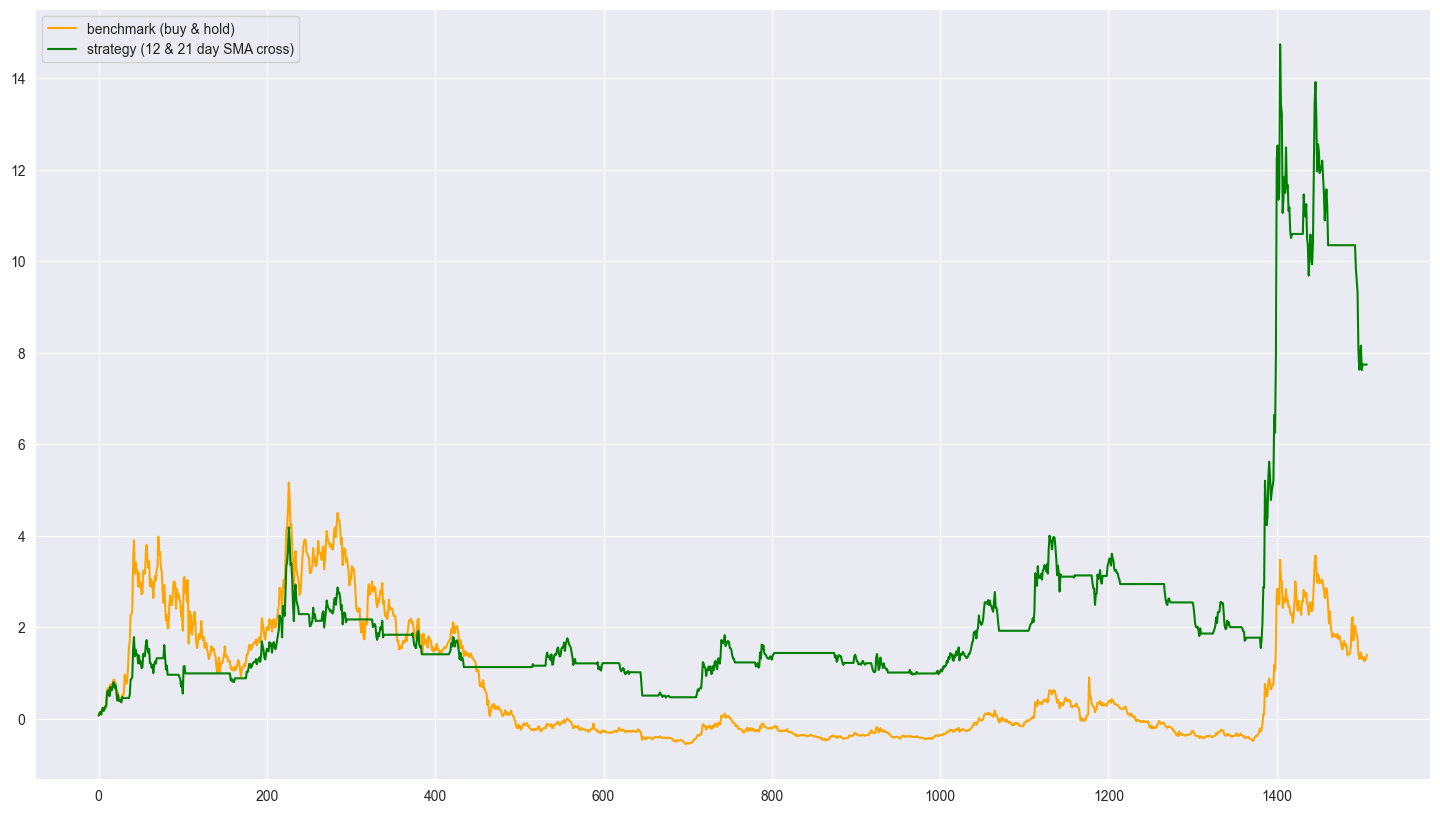

In [186]:
# Plot Equity Curve
fig = plt.figure(figsize=(18, 10))
plt.plot(df_main["benchmark_product_exp"].values, color="orange")
plt.plot(df_main["strategy_product_exp"].values, color="green")
plt.legend(["benchmark (buy & hold)", "strategy (12 & 21 day SMA cross)"])
plt.show()